In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/drive/MyDrive/fake_or_real_news.csv')
df

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


In [25]:
import pandas as pd
import numpy as np

In [26]:
df=pd.read_csv('/content/drive/MyDrive/fake_or_real_news.csv')

In [27]:
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [28]:
df.shape

(6335, 4)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [30]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [31]:
df=df.drop(['Unnamed: 0','title'],axis=1)

In [32]:
df

,text,label
0,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,It's primary day in New York and front-runners...,REAL
...,...,...
6330,The State Department told the Republican Natio...,REAL
6331,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,"ADDIS ABABA, Ethiopia —President Obama convene...",REAL


In [33]:
df.head

<bound method NDFrame.head of                                                    text label
0     Daniel Greenfield, a Shillman Journalism Fello...  FAKE
1     Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE
2     U.S. Secretary of State John F. Kerry said Mon...  REAL
3     — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE
4     It's primary day in New York and front-runners...  REAL
...                                                 ...   ...
6330  The State Department told the Republican Natio...  REAL
6331  The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...  FAKE
6332   Anti-Trump Protesters Are Tools of the Oligar...  FAKE
6333  ADDIS ABABA, Ethiopia —President Obama convene...  REAL
6334  Jeb Bush Is Suddenly Attacking Trump. Here's W...  REAL

[6335 rows x 2 columns]>

# NLP STEPS

In [34]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [35]:
stem_port=PorterStemmer()

In [36]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
def stemming(content):
  stemmed_content=re.sub('[^a-zA-Z]',' ',content)
  stemmed_content=stemmed_content.lower()
  stemmed_content=stemmed_content.split()
  stemmed_content=[stem_port.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
  stemmed_content=' '.join(stemmed_content)
  return stemmed_content


In [ ]:
df['text']=df['text'].apply(stemming)

In [39]:
df.head()

,text,label
0,daniel greenfield shillman journal fellow free...,FAKE
1,googl pinterest digg linkedin reddit stumbleup...,FAKE
2,u secretari state john f kerri said monday sto...,REAL
3,kayde king kaydeek novemb lesson tonight dem l...,FAKE
4,primari day new york front runner hillari clin...,REAL


In [40]:
x=df['text'].values
y=df['label'].values

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [42]:
vectorizer=TfidfVectorizer()
vectorizer.fit(x)
x=vectorizer.transform(x)

In [43]:
print(x)

  (0, 106)	0.02761351227547292
  (0, 212)	0.023325671822305483
  (0, 271)	0.054392547007153
  (0, 328)	0.060358339691341766
  (0, 357)	0.013921754610837712
  (0, 451)	0.020578335403474236
  (0, 578)	0.07906058794712593
  (0, 617)	0.019850889079147057
  (0, 620)	0.01867769280554434
  (0, 622)	0.044611051373187424
  (0, 648)	0.015493583340569357
  (0, 680)	0.019224695171899866
  (0, 978)	0.0267316264615063
  (0, 999)	0.020738114075644642
  (0, 1022)	0.0371485992478585
  (0, 1033)	0.014808690907292291
  (0, 1085)	0.028815013247480384
  (0, 1089)	0.018102417756284926
  (0, 1197)	0.022505695388032227
  (0, 1206)	0.010675511636980443
  (0, 1549)	0.02507693986049084
  (0, 1665)	0.025967702221880915
  (0, 1713)	0.041128098634750046
  (0, 1744)	0.027618563562476325
  (0, 1783)	0.018872240981032625
  :	:
  (6334, 39650)	0.02398512016423436
  (6334, 39971)	0.04071827532138649
  (6334, 40086)	0.03890236771964674
  (6334, 40158)	0.04886237540126324
  (6334, 40783)	0.05859961268767996
  (6334, 41309

In [44]:
df.shape

(6335, 2)

In [45]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)

**MODEL BUILDING**

In [46]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array(['REAL', 'FAKE', 'FAKE', ..., 'REAL', 'REAL', 'REAL'], dtype=object)

In [47]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.9163378058405682

In [48]:
news='Watch The Extract Moment Paul Rayan Commited Suicide At A Trump Rally(VIDEO)'

In [49]:
news=stemming(news)

In [50]:
import numpy as np

In [51]:
model.predict(vectorizer.transform(np.array([news])))

array(['FAKE'], dtype=object)

In [52]:
#startification- ensure that both train and text set has equal proportion of each class.

#without startification result in unequal distribution of classes.

In [53]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
svm_model = SVC()
rf_model = RandomForestClassifier()
ada_model = AdaBoostClassifier()

lst_model=[svm_model,rf_model,ada_model]

In [54]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay

In [55]:
print(y_train.shape)
print(y_test.shape)

(5068,)
(1267,)


SVC()
****************************************************************************************************
              precision    recall  f1-score   support

        FAKE       0.91      0.96      0.93       633
        REAL       0.96      0.90      0.93       634

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267

****************************************************************************************************
RandomForestClassifier()
****************************************************************************************************
              precision    recall  f1-score   support

        FAKE       0.89      0.91      0.90       633
        REAL       0.91      0.89      0.90       634

    accuracy                           0.90      1267
   macro avg       0.90      0.90      0.90      1267
weighted avg       0.90      0.90      0.90      1267

************

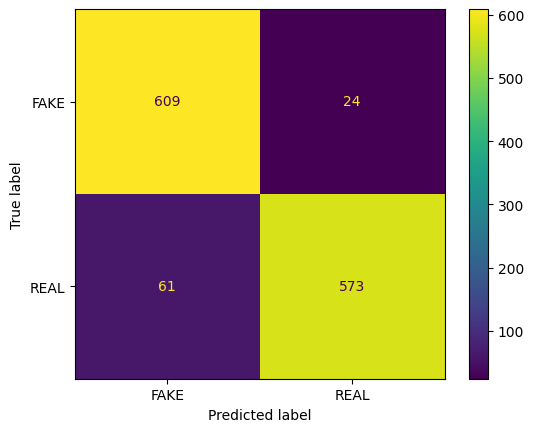

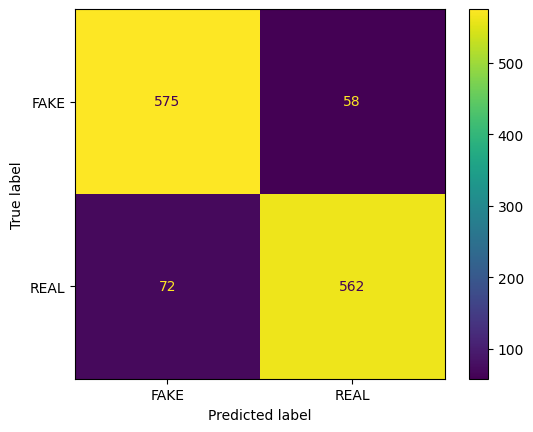

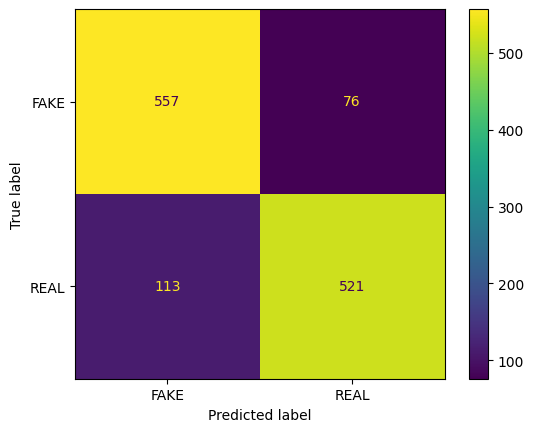

In [56]:
for i in lst_model:
  print(i)
  i.fit(x_train,y_train)
  y_predict=i.predict(x_test)
  print('*'*100)
  print(classification_report(y_test,y_predict))
  print('*'*100)
  print(ConfusionMatrixDisplay.from_predictions(y_test,y_predict))